In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('/content/Dataset .csv')

In [ ]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


LEVEL 3 TASK1. Restarauent Reviews


Ques.1- Analyze the text reviews to identify the most
common positive and negative keywords

In [ ]:
rating_text_counts = df['Rating text'].value_counts()
print(rating_text_counts)

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [ ]:
positive_ratings = ['Excellent', 'Very Good', 'Good']
negative_ratings = ['Poor']
neutral_ratings = ['Average']

def categorize_sentiment(rating_text):
    if rating_text in positive_ratings:
        return 'Positive'
    elif rating_text in negative_ratings:
        return 'Negative'
    elif rating_text in neutral_ratings:
        return 'Neutral'
    else:
        return 'Other'

df['Sentiment'] = df['Rating text'].apply(categorize_sentiment)
print(df[['Rating text', 'Sentiment']].head())
print(df['Sentiment'].value_counts())

  Rating text Sentiment
0   Excellent  Positive
1   Excellent  Positive
2   Very Good  Positive
3   Excellent  Positive
4   Excellent  Positive
Sentiment
Neutral     3737
Positive    3480
Other       2148
Negative     186
Name: count, dtype: int64


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()
print("Frequency of each sentiment category:\n", sentiment_counts)

Frequency of each sentiment category:
 Sentiment
Neutral     3737
Positive    3480
Other       2148
Negative     186
Name: count, dtype: int64


/tmp/ipython-input-774794291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


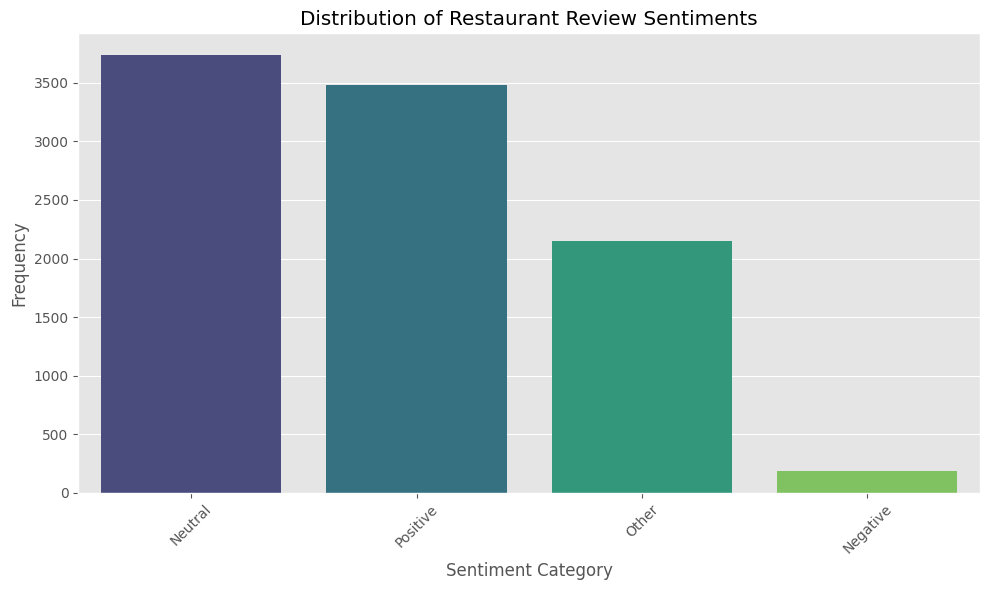

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.xlabel('Sentiment Category')
plt.ylabel('Frequency')
plt.title('Distribution of Restaurant Review Sentiments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q2. The average length of reviews and
explore if there is a relationship between
review length and rating


Average Review Length: 7.020730813527379


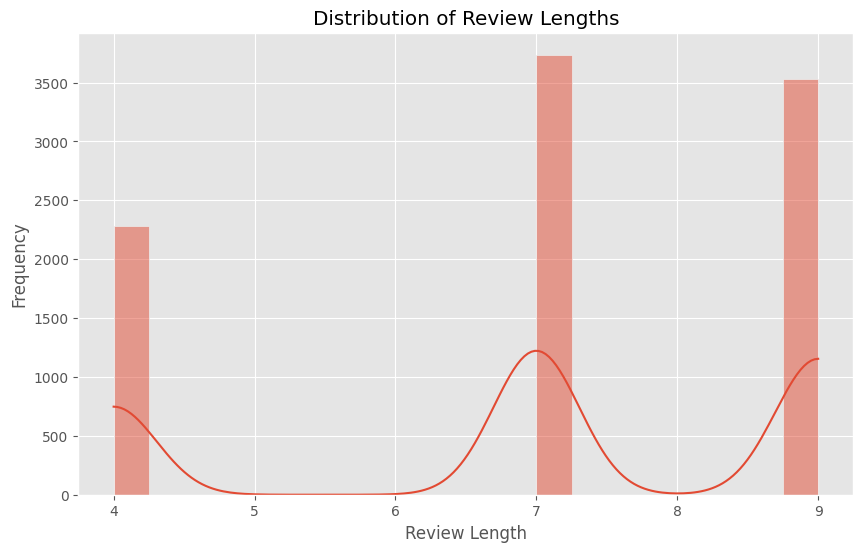

In [ ]:
average_review_length = df['Rating text'].apply(len).mean()
print("Average Review Length:", average_review_length)

plt.figure(figsize=(10, 6))
sns.histplot(df['Rating text'].apply(len), bins=20, kde=True)
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.show()

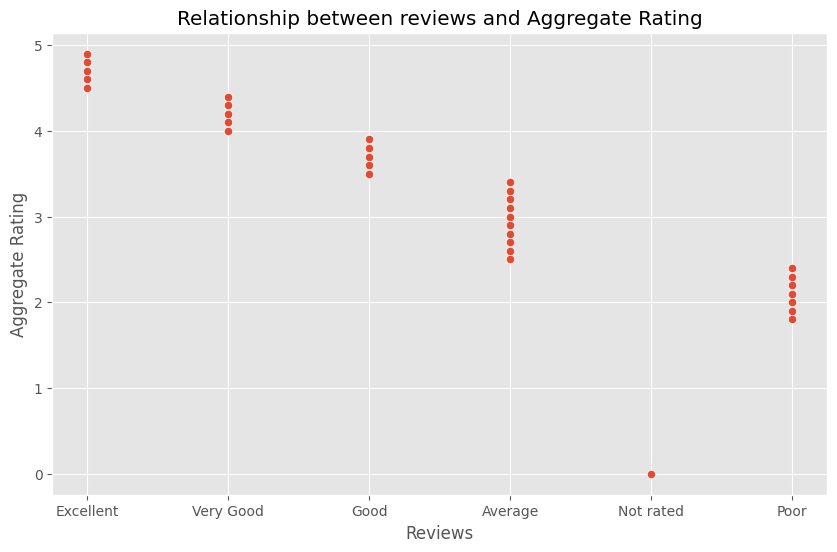

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating text', y='Aggregate rating', data=df)
plt.title('Relationship between reviews and Aggregate Rating')
plt.xlabel('Reviews')
plt.ylabel('Aggregate Rating')
plt.show()

Task 2-- vote analysis


Q1. Identify the restaurants with the highest and
lowest number of votes

In [ ]:
restaurants_with_highest_votes = df.nlargest(10, 'Votes')
restaurants_with_lowest_votes = df.nsmallest(10, 'Votes')
print("Restaurants with the highest number of votes:")
print(restaurants_with_highest_votes[['Restaurant Name', 'Votes']])
print("\nRestaurants with the lowest number of votes:")
print(restaurants_with_lowest_votes[['Restaurant Name', 'Votes']])



Restaurants with the highest number of votes:
                Restaurant Name  Votes
728                        Toit  10934
735                    Truffles   9667
3994           Hauz Khas Social   7931
2412                  Peter Cat   7574
739   AB's - Absolute Barbecues   6907
2414            Barbeque Nation   5966
743                 Big Brewsky   5705
2307  AB's - Absolute Barbecues   5434
736             The Black Pearl   5385
2411                      BarBQ   5288

Restaurants with the lowest number of votes:
        Restaurant Name  Votes
69     Cantinho da Gula      0
874       The Chaiwalas      0
879  Fusion Food Corner      0
880       Punjabi Rasoi      0
887       Baskin Robbin      0
900              Angaar      0
901               TcozY      0
902       The Retriever      0
905      Chill 'N Grill      0
906  Punjabi Restaurant      0


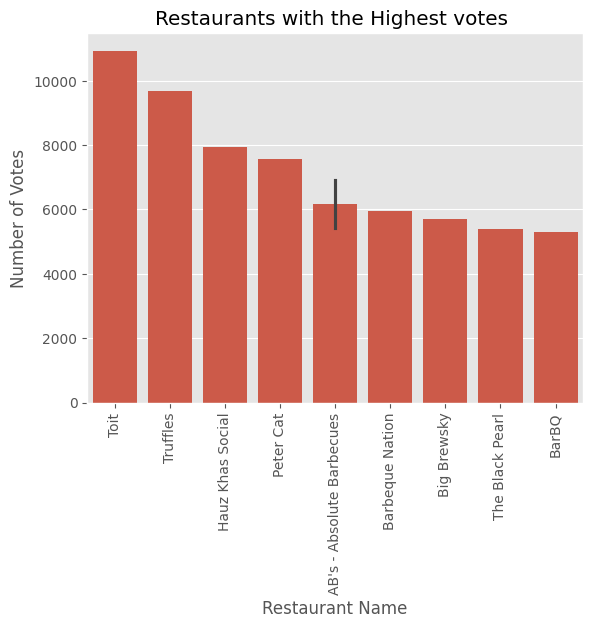

In [ ]:
sns.barplot(x='Restaurant Name', y='Votes', data=restaurants_with_highest_votes)
plt.xticks(rotation=90)
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Votes')
plt.title('Restaurants with the Highest votes ')
plt.show()


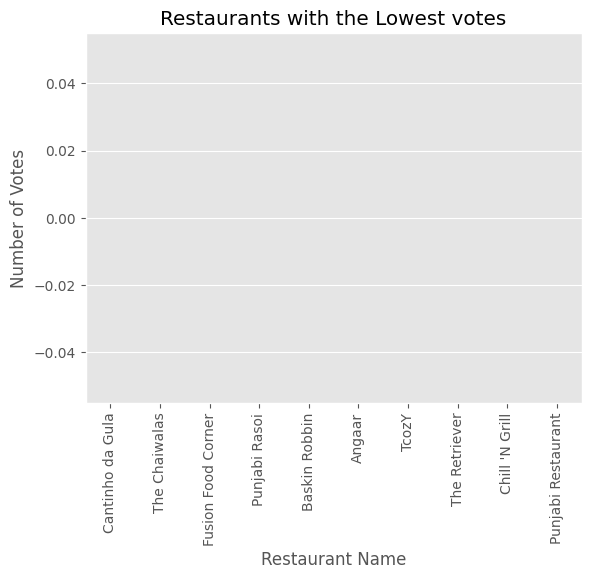

In [ ]:
sns.barplot(x='Restaurant Name', y='Votes', data=restaurants_with_lowest_votes)
plt.xticks(rotation=90)
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Votes')
plt.title('Restaurants with the Lowest votes')
plt.show()


Q2. Analyze if there is a correlation between the
number of votes and the rating of a
restaurant

Correlation between Votes and Aggregate Rating: 0.31369058419541157


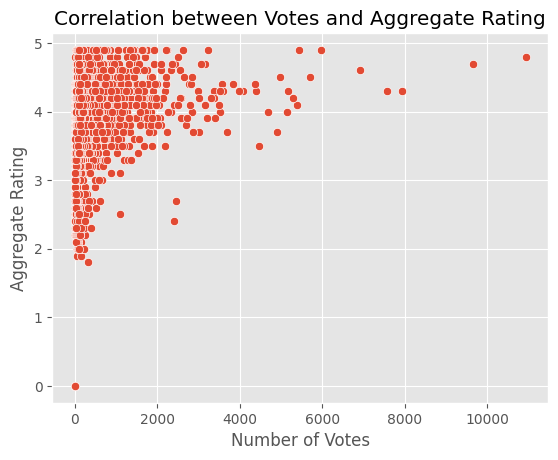

In [ ]:
correlation_votes_rating = df['Votes'].corr(df['Aggregate rating'])
print("Correlation between Votes and Aggregate Rating:", correlation_votes_rating)
sns.scatterplot(x='Votes', y='Aggregate rating', data=df)
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.title('Correlation between Votes and Aggregate Rating')
plt.show()

Task-3 Price range vs table booking and online delivery

Q1. Analyze if there is a relationship between the
price range and the availability of online
delivery and table booking

In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Sentiment'],
      dtype='object')

In [ ]:
df['Has Online delivery'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['Has Table booking'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
sns.set_style("whitegrid")

df['Has Online delivery'] = (
    df['Has Online delivery']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

df['Has Table booking'] = (
    df['Has Table booking']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)


price_group = df.groupby('Price range').agg({
    'Has Online delivery': 'mean',
    'Has Table booking': 'mean'
}).reset_index()


price_group['Has Online delivery'] *= 100
price_group['Has Table booking'] *= 100

print(price_group)


   Price range  Has Online delivery  Has Table booking
0            1                  NaN                NaN
1            2                  NaN                NaN
2            3                  NaN                NaN
3            4                  NaN                NaN


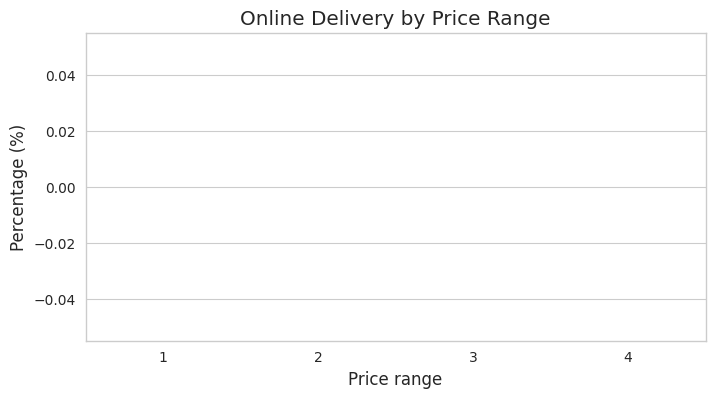

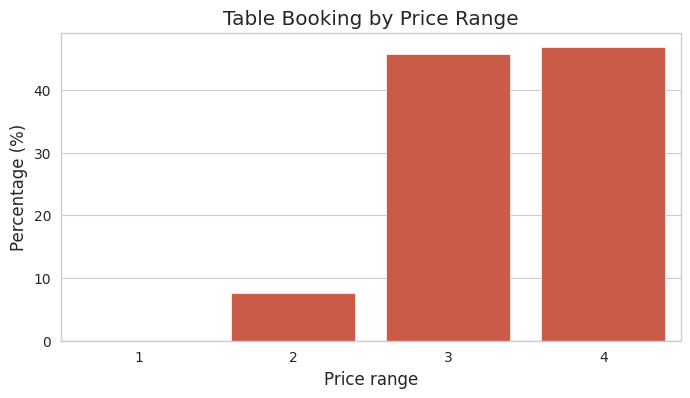

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x='Price range', y='Has Online delivery', data=price_group)
plt.title('Online Delivery by Price Range')
plt.ylabel('Percentage (%)')
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(x='Price range', y='Has Table booking', data=price_group)
plt.title('Table Booking by Price Range')
plt.ylabel('Percentage (%)')
plt.show()


Q2. Determine if higher-priced restaurants are
more likely to offer these services.

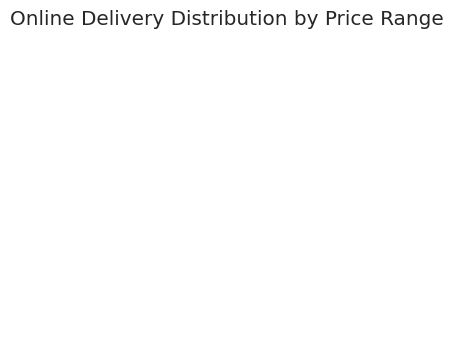

In [ ]:
online_delivery_df = df[df['Has Online delivery'] == 1]

price_group_counts = online_delivery_df['Price range'].value_counts()

price_group_percentages = (price_group_counts / price_group_counts.sum()) * 100

plt.figure(figsize=(8,4))
plt.pie(
    price_group_percentages,
    labels=price_group_percentages.index,
    autopct='%.1f%%',
    startangle=90,
    shadow=True
)

plt.title('Online Delivery Distribution by Price Range')
plt.show()
